<a href="https://colab.research.google.com/github/fatma12ismail-hue/FilmOneri/blob/main/Colab'e_ho%C5%9F_geldiniz_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi yüklüyoruz (Titanic veri seti)
df = sns.load_dataset('titanic')

print("Veri yüklendi! İlk 5 satır aşağıda:")
df.head()

Veri yüklendi! İlk 5 satır aşağıda:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Eksik veri sayıları:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


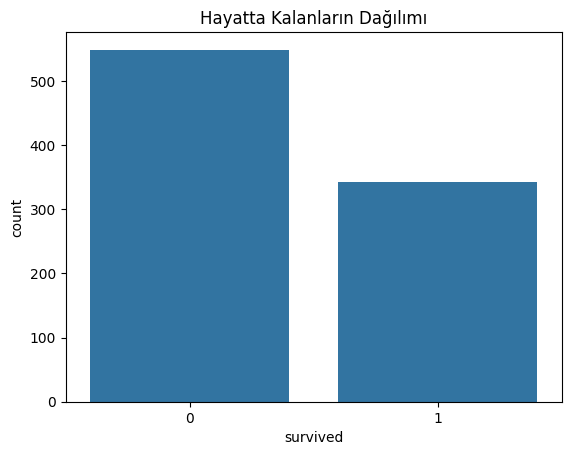

In [2]:
# Eksik veri analizi
print("Eksik veri sayıları:")
print(df.isnull().sum())

# Boş yaşları ortalama ile doldur (Temizlik)
df['age'] = df['age'].fillna(df['age'].mean())

# Grafik çizdirme (Görselleştirme)
sns.countplot(x='survived', data=df)
plt.title('Hayatta Kalanların Dağılımı')
plt.show()

In [9]:
# Girdileri ve hedefi belirle
X = df[['pclass', 'age', 'sibsp', 'parch', 'fare']]
y = df['survived']

# Veriyi böl (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Modeli eğit
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model eğitildi. Tahmine hazır!")

Model eğitildi. Tahmine hazır!


In [10]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy (Doğruluk):", accuracy_score(y_test, y_pred))
print("\nDetaylı Rapor:\n", classification_report(y_test, y_pred))

Accuracy (Doğruluk): 0.7318435754189944

Detaylı Rapor:
               precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.77      0.50      0.61        74

    accuracy                           0.73       179
   macro avg       0.74      0.70      0.70       179
weighted avg       0.74      0.73      0.72       179

